# LST Thermal — 1 m Sharpened Temperature (Sousse, Tunisia — 35.8256°N, 10.641°E)

*Track: lst-thermal track · needs AWS creds.*

**Case study:** Sousse, Tunisia (35.8256°N, 10.641°E) — Gulf of Hammamet, 2026-08-14. LST is **measured** by Landsat 8/9 Collection 2 L2 `ST_B10` (30 m, `K=DN×0.00341802+149.0`) and sharpened to your 1 m `MS.tif` grid via TsHARP: `LST_30m = a+b·NDVI_30m` (least squares on clear 30 m pixels) + bilinear residuals → `LST_1m = a+b·NDVI_1m + resid_1m`. Preserves coarse means. Output: `indices/thermal/lst.tiff` float32 **Celsius** (K−273.15), NoData=NaN, plus `lst_legend.json`.

**This notebook is Sousse-only — Huntington Beach oil is in `02`, Doha mosaic in `04`, general demo in `01`.**


## 0. AWS config — required for LST (usgs-landsat is Requester Pays)

Without this, LST is skipped with `aws-credentials` note and the run still succeeds. Three ways (pick one):
1. **Env vars** (temporary, for this shell/notebook): `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, `AWS_SESSION_TOKEN` (if STS)
2. **File** `~/.aws/credentials` (persistent):
   ```ini
   [default]
   aws_access_key_id = ...
   aws_secret_access_key = ...
   # aws_session_token = ...  # if temporary
   ```
3. **Instance role** (EC2) — no config needed

Reads are windowed COG range requests (KB-scale, fractions of a cent). Verify below.

In [1]:
import os, pathlib, json, subprocess, sys
from pathlib import Path
print("Env:", {k: ("***"+v[-4:] if v else "unset") for k,v in {
    "AWS_ACCESS_KEY_ID": os.environ.get("AWS_ACCESS_KEY_ID",""),
    "AWS_SECRET_ACCESS_KEY": os.environ.get("AWS_SECRET_ACCESS_KEY",""),
    "AWS_SESSION_TOKEN": os.environ.get("AWS_SESSION_TOKEN",""),
}.items()})
creds = Path.home() / ".aws" / "credentials"
print("~/.aws/credentials exists:", creds.exists())
if creds.exists():
    print(creds.read_text().splitlines()[0][:40])
# quick boto check if available
try:
    import botocore.session
    sess = botocore.session.Session()
    print("botocore credentials:", sess.get_credentials() is not None)
except Exception as e:
    print("botocore not installed or no creds:", e)
# optional: set from notebook (uncomment, paste, run, then clear)
# os.environ["AWS_ACCESS_KEY_ID"] = "ASIA..."
# os.environ["AWS_SECRET_ACCESS_KEY"] = "..."
# os.environ["AWS_SESSION_TOKEN"] = "..."  # if STS
# print("set")


Env: {'AWS_ACCESS_KEY_ID': 'unset', 'AWS_SECRET_ACCESS_KEY': 'unset', 'AWS_SESSION_TOKEN': 'unset'}
~/.aws/credentials exists: False


botocore credentials: False


### S3 reachability check — no full-scene download

Probes Landsat ST access with a tiny 30 m window; missing creds raise a clear, expected error.

In [2]:
# Test the S3 path without downloading a full scene (small 30 m window)
import rasterio
# This will raise LSTUnavailable(aws-credentials) if creds are missing — expected
try:
    from pathlib import Path
    import sys
    _r = Path.cwd()
    for _up in [_r, *_r.parents]:
        if (_up / 'scripts' / 'lst.py').exists():
            sys.path.insert(0, str(_up / 'scripts'))
            break
    import lst
    print("lst.ST_MULT", lst.ST_MULT_USGS, "230–360 K gate", lst.PLAUSIBLE_K_MIN, lst.PLAUSIBLE_K_MAX)
    # dry check — does not hit S3
    print("search window for 2026-08-14:", lst.window_range("2026-08-14"))
except Exception as e:
    print(e)


lst.ST_MULT 0.00341802 230–360 K gate 230.0 360.0
search window for 2026-08-14: ('2026-07-29', '2026-08-15')


## 1. Setup — find latest run with thermal

In [3]:
from pathlib import Path
import glob
ROOT = Path.cwd()
for _up in [ROOT, *ROOT.parents]:  # walk up: works from notebooks/<track>/ too
    if (_up / 'scripts' / 'run_location.py').exists():
        ROOT = _up
        break
cands = sorted(p for p in glob.glob(str(ROOT / "outputs" / "TN" / "*" / "*"))  # Sousse only
                if (Path(p) / "MS.tif").exists())  # latest run that has products
run_dir = Path(cands[-1]) if cands else None
print(run_dir)
MS = run_dir / "MS.tif" if run_dir else None
LST = run_dir / "indices" / "thermal" / "lst.tiff" if run_dir else None
print("MS", MS.exists() if MS else False, "LST", LST.exists() if LST else False)
if LST and LST.exists():
    import rasterio
    with rasterio.open(LST) as s:
        print(f"LST {s.width}x{s.height} {s.dtypes[0]} {s.descriptions[0]} {s.tags().get('LST_UNITS')}")
        print(s.tags(1).get("LST_LEGEND","")[:120])
else:
    print("No LST — rerun with creds: AWS_ACCESS_KEY_ID=... python scripts/run_location.py --lon 10.641 --lat 35.8256 --date 2026-08-14")
D_TXT = run_dir.parent.name if run_dir else 'no-date'


/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/sousse-lst-0814
MS True LST True
LST 4120x4120 float32 LST (Celsius, land-fit) Celsius
LST 1 m land-fit (Celsius) — min 28.74 C, max 49.78 C, mean 38.33 C, median 42.82 C, p2 29.02 C, p98 47.68 C; fit exclud


## 2. Visualize — LST (Celsius) + NDVI (1 m)

/tmp/ipykernel_128997/117210779.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


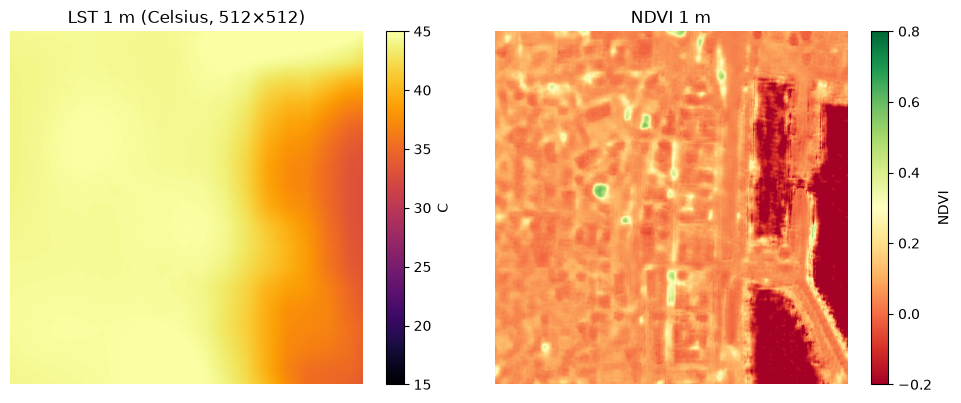

LST 32.8–45.9 C  mean 42.5  NDVI 0.034


In [4]:
import rasterio, numpy as np, matplotlib.pyplot as plt
if LST and LST.exists():
    w=512; y0,x0=2048-256,2048-256
    with rasterio.open(LST) as s:
        lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    with rasterio.open(MS) as s:
        dn=s.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)/10000
        ndvi=np.where((dn[3]+dn[2])==0, np.nan, (dn[3]-dn[2])/(dn[3]+dn[2]))
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    im=ax[0].imshow(lst, cmap="inferno", vmin=15, vmax=45); plt.colorbar(im, ax=ax[0], label="C"); ax[0].set_title("LST 1 m (Celsius, 512×512)"); ax[0].axis("off")
    im=ax[1].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8); plt.colorbar(im, ax=ax[1], label="NDVI"); ax[1].set_title("NDVI 1 m"); ax[1].axis("off")
    plt.tight_layout(); plt.show()
    print(f"LST {np.nanmin(lst):.1f}–{np.nanmax(lst):.1f} C  mean {np.nanmean(lst):.1f}  NDVI {np.nanmean(ndvi):.3f}")
else:
    print("Need LST")


## 3. Chart — LST histogram (Celsius) + legend

LST 1 m land-fit (Celsius) — min 28.74 C, max 49.78 C, mean 38.33 C, median 42.82 C, p2 29.02 C, p98 47.68 C; fit excludes sea (MNDWI>0)
units Celsius  min 28.742034912109375 max 49.782562255859375
sidecar True


/tmp/ipykernel_128997/1460186566.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lst=s.read(1); tags=s.tags()


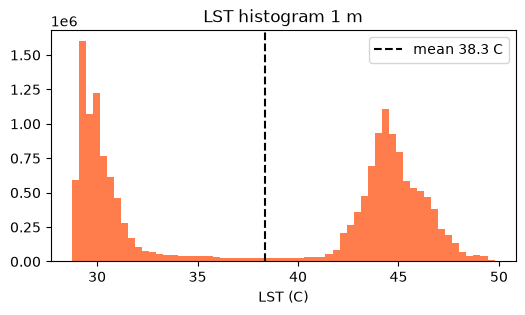

LST 1 m land-fit (Celsius) — min 28.74 C, max 49.78 C, mean 38.33 C, median 42.82 C, p2 29.02 C, p98 47.68 C; fit excludes sea (MNDWI>0)


In [5]:
import rasterio, numpy as np, matplotlib.pyplot as plt, json
from pathlib import Path
if LST and LST.exists():
    with rasterio.open(LST) as s:
        lst=s.read(1); tags=s.tags()
        legend=s.tags(1).get("LST_LEGEND","")
        print(legend)
        print(f"units {tags.get('LST_UNITS')}  min {tags.get('LST_MIN_C')} max {tags.get('LST_MAX_C')}")
        print(f"sidecar {Path(LST).with_name('lst_legend.json').exists()}")
        m=np.isfinite(lst)
        plt.figure(figsize=(6,3)); plt.hist(lst[m].ravel(), bins=60, color="orangered", alpha=0.7); plt.axvline(np.nanmean(lst), color="black", ls="--", label=f"mean {np.nanmean(lst):.1f} C"); plt.legend(); plt.xlabel("LST (C)"); plt.title("LST histogram 1 m"); plt.show()
    # also show sidecar
    print(json.loads(Path(LST).with_name("lst_legend.json").read_text())["legend"])


## 4. LST vs NDVI — 2D histogram + fit (TsHARP diagnostics)
The run README records the fit: `LST = intercept + slope·NDVI` over ~5k clear 30 m pixels, RMSE in K. This cell reproduces the scatter at 1 m.

1 m fit: LST = 41.92 + 18.13·NDVI  (compare to 30 m fit in run README)


/tmp/ipykernel_128997/2948349775.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


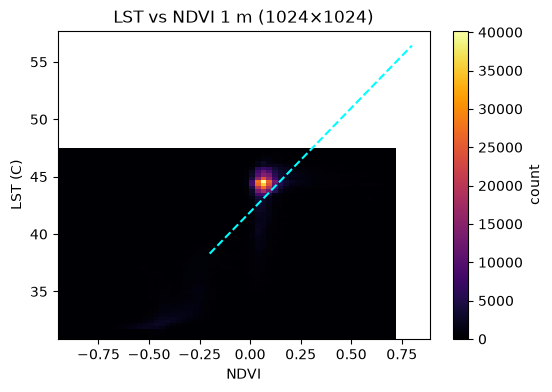

In [6]:
import rasterio, numpy as np, matplotlib.pyplot as plt
if LST and LST.exists():
    w=1024; y0,x0=2048-512,2048-512
    with rasterio.open(MS) as s:
        dn=s.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)/10000
        ndvi=np.where((dn[3]+dn[2])==0, np.nan, (dn[3]-dn[2])/(dn[3]+dn[2]))
    with rasterio.open(LST) as s:
        lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    m=np.isfinite(ndvi)&np.isfinite(lst)
    # linear fit at 1 m (diagnostic, not the 30 m fit)
    slope, intercept = np.polyfit(ndvi[m].ravel(), lst[m].ravel(), 1)
    print(f"1 m fit: LST = {intercept:.2f} + {slope:.2f}·NDVI  (compare to 30 m fit in run README)")
    plt.figure(figsize=(6,4)); plt.hist2d(ndvi[m], lst[m], bins=60, cmap="inferno"); plt.colorbar(label="count"); plt.plot([-0.2,0.8], [intercept+slope*(-0.2), intercept+slope*0.8], color="cyan", ls="--"); plt.xlabel("NDVI"); plt.ylabel("LST (C)"); plt.title("LST vs NDVI 1 m (1024×1024)"); plt.show()
else:
    print("Need LST")


## 5. If LST is missing — generate it on the existing MS.tif (needs AWS creds)
No need to re-run the 5 min S2SR. This cell sharpening-only on the already super-resolved cube.

In [7]:
# from pathlib import Path
# import sys; sys.path.insert(0, str(ROOT / "scripts"))
# from lst import compute_lst
# import sys; sys.path.insert(0, str(ROOT / "scripts" / "local_engine"))
# import datautils
# # Use the run's center lon/lat — read from run README or set manually
# # lon, lat = 10.641, 35.8256
# # aoi = datautils.aoi_from_xy((lon, lat), km=6)
# # rec = compute_lst(MS, "2026-08-14", aoi["bbox"])
# # print(rec)
print("Uncomment and set lon/lat/date + AWS creds, then run")


Uncomment and set lon/lat/date + AWS creds, then run


## 6. Anomalies + SUHI — hot/cold spots, sea baseline (needs lst.tiff)

Sea (MNDWI>0) anchors the rural cool baseline; built (NDBI>0.05) vs sea gives SUHI intensity. Hot spots exceed mean+2σ. Skips cleanly until thermal exists.


/tmp/ipykernel_128997/185654326.py:11: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  _raw = _s.read(1, window=_w).astype(float)
/tmp/ipykernel_128997/185654326.py:16: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  _ndvi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)
/tmp/ipykernel_128997/185654326.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  _mndwi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)


LST C: mean 40.0 std 6.1 p5 30.1 p95 46.1
sea 31.8 C | built 43.7 C | SUHI +11.9 K
hot spots 0.00%  cold spots 0.00%


/tmp/ipykernel_128997/185654326.py:20: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  _ndbi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)


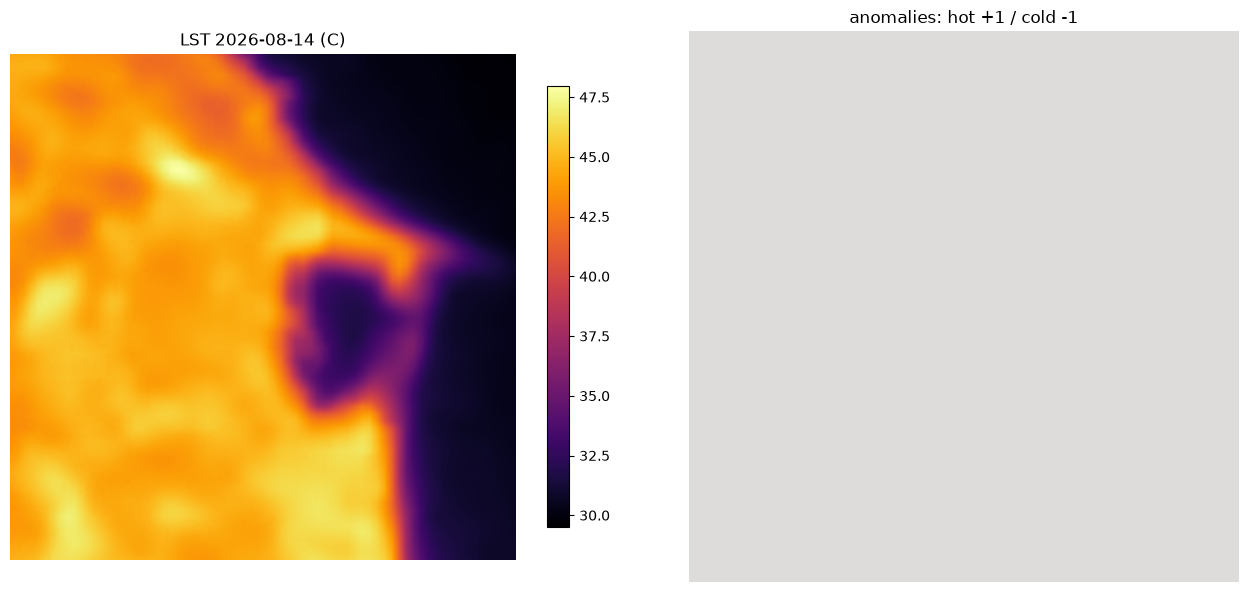

wrote LST_anomalies.png


In [8]:
# Anomaly + SUHI analysis on a 2048px center chip (fast; full-res identical method)
import numpy as _np, matplotlib.pyplot as _plt, rasterio as _r
from rasterio.windows import Window as _W
if LST is None or not LST.exists():
    print('pending: no lst.tiff — generate with fresh AWS creds, then re-run this notebook')
else:
    CH = 2048
    with _r.open(LST) as _s:
        Hh, Ww = _s.height, _s.width
        _w = _W((Ww - CH)//2, (Hh - CH)//2, CH, CH)
        _raw = _s.read(1, window=_w).astype(float)
        _units = (_s.tags().get('LST_UNITS') or '').lower()
        _k = _raw - 273.15 if ('kelvin' in _units or _np.nanmedian(_raw) > 200) else _raw  # Celsius
        _tr = _s.window_transform(_w)
    with _r.open(run_dir / 'indices' / 'vegetation' / 'ndvi.tiff') as _s:
        _ndvi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)
    with _r.open(run_dir / 'indices' / 'water' / 'mndwi.tiff') as _s:
        _mndwi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)
    with _r.open(run_dir / 'indices' / 'soil_urban' / 'ndbi.tiff') as _s:
        _ndbi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)
    _v = _k[_np.isfinite(_k)]
    _mu, _sd = float(_np.mean(_v)), float(_np.std(_v))
    _sea = _k[_mndwi > 0]; _bld = _k[_ndbi > 0.05]
    _suhi = float(_np.nanmean(_bld) - _np.nanmean(_sea))
    _hot = (_k > _mu + 2*_sd) & _np.isfinite(_k); _cold = (_k < _mu - 2*_sd) & _np.isfinite(_k)
    print(f'LST C: mean {_mu:.1f} std {_sd:.1f} p5 {_np.percentile(_v,5):.1f} p95 {_np.percentile(_v,95):.1f}')
    print(f'sea {float(_np.nanmean(_sea)):.1f} C | built {float(_np.nanmean(_bld)):.1f} C | SUHI {_suhi:+.1f} K')
    print(f'hot spots {100*_hot.sum()/_v.size:.2f}%  cold spots {100*_cold.sum()/_v.size:.2f}%')
    fig, ax = _plt.subplots(1, 2, figsize=(13, 6))
    im = ax[0].imshow(_np.clip(_k, _mu-2*_sd, _mu+2*_sd), cmap='inferno'); ax[0].set_title(f'LST {D_TXT} (C)'); _plt.colorbar(im, ax=ax[0], shrink=0.8)
    ax[1].imshow(_np.where(_hot, 1, _np.where(_cold, -1, 0)), vmin=-1, vmax=1, cmap='coolwarm'); ax[1].set_title('anomalies: hot +1 / cold -1')
    for _a in ax: _a.axis('off')
    fig.tight_layout(); fig.savefig(run_dir / 'LST_anomalies.png', dpi=130)
    _plt.show()
    print('wrote LST_anomalies.png')


## 7. Green-zone cooling — strata LST, park cool island, efficiency (needs lst.tiff)

NDVI strata share the same sun + wind, so their LST gap isolates vegetation cooling. Efficiency = ΔT per 0.1 NDVI from the LST–NDVI fit.


_bare   frac 0.575  LST 44.0 C
sparse  frac 0.056  LST 44.1 C
green   frac 0.026  LST 44.2 C
dense   frac 0.017  LST 43.6 C
park cool island (dense − bare): -0.3 K
cooling efficiency +0.10 K per +0.1 NDVI (fit LST=1.0*NDVI+43.8)


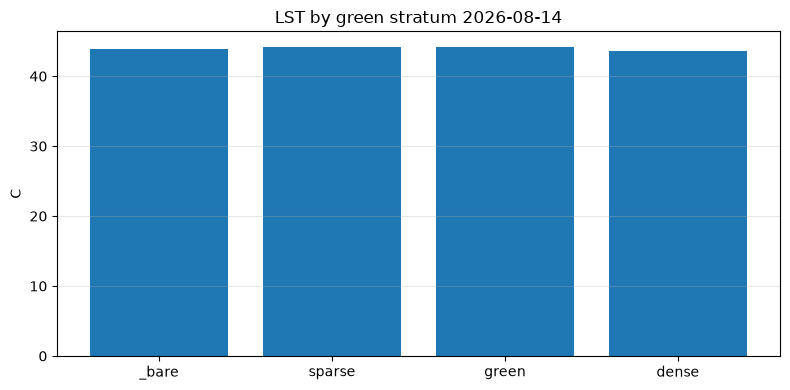

wrote LST_green_cooling.png


In [9]:
# Vegetation cooling: mean LST per NDVI stratum + cool-island intensity
if LST is None or not LST.exists():
    print('pending: no lst.tiff')
else:
    _land = (_mndwi <= 0) & _np.isfinite(_k)  # strata are land-only; sea keeps its own baseline
    _bins = [('_bare', -9, 0.20), ('sparse', 0.20, 0.35), ('green', 0.35, 0.50), ('dense', 0.50, 9)]
    _rows = []
    for _n, _lo, _hi in _bins:
        _m = (_ndvi >= _lo) & (_ndvi < _hi) & _land
        _rows.append((_n, float(_m.mean()), float(_np.nanmean(_k[_m])) if _m.any() else float('nan')))
        print(f"{_n:7s} frac {_rows[-1][1]:.3f}  LST {_rows[-1][2]:.1f} C")
    _pci = [r[2] for r in _rows if r[0] == 'dense'][0] - [r[2] for r in _rows if r[0] == '_bare'][0]
    print(f'park cool island (dense − bare): {_pci:+.1f} K')
    _ok = _np.isfinite(_k) & _np.isfinite(_ndvi) & (_mndwi <= 0)
    _A = _np.vstack([_ndvi[_ok], _np.ones(_ok.sum())]).T
    _sl, _ic = _np.linalg.lstsq(_A, _k[_ok], rcond=None)[0]
    print(f'cooling efficiency {_sl*0.1:+.2f} K per +0.1 NDVI (fit LST={_sl:.1f}*NDVI+{_ic:.1f})')
    fig, ax = _plt.subplots(figsize=(8, 4))
    ax.bar([r[0] for r in _rows], [r[2] for r in _rows])
    ax.set_title(f'LST by green stratum {D_TXT}'); ax.set_ylabel('C'); ax.grid(alpha=0.3, axis='y')
    fig.tight_layout(); fig.savefig(run_dir / 'LST_green_cooling.png', dpi=130)
    _plt.show()
    print('wrote LST_green_cooling.png')


## 8. Cooling-energy demand proxy — CDH × built fraction (needs lst.tiff)

Per-pixel cooling-degree-hours above 26°C, weighted by built fraction (NDBI 0–1): a *relative* AC-load index, not kWh — no building height, occupancy or AC-penetration data. Zonal totals rank districts.


city mean load-index 3.79 (C·built-frac); peak 21.0
top-20% cells carry 50.4% of load; top-5%: 16.4%


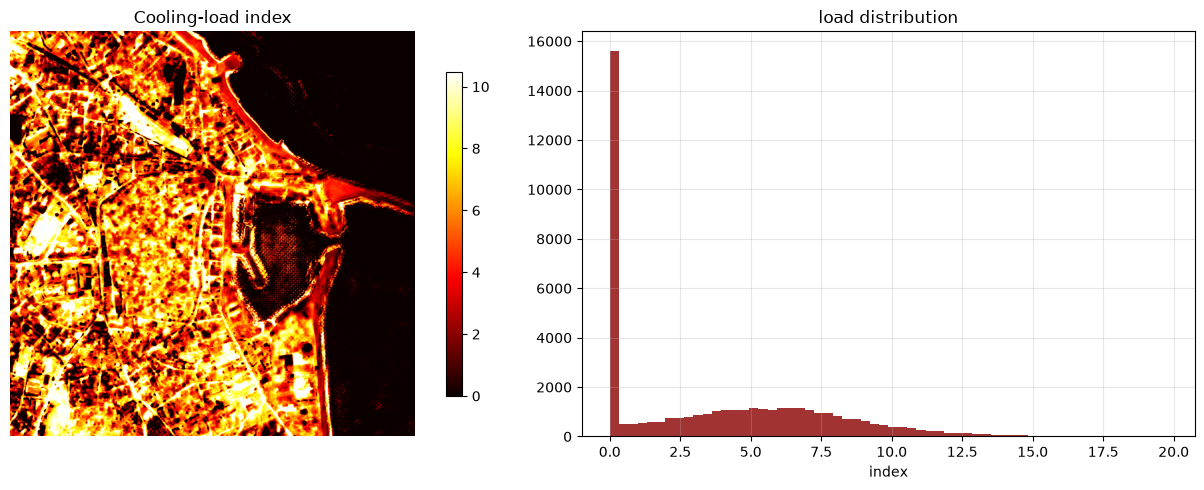

wrote LST_cooling_load.png


In [10]:
# Relative cooling-load index: max(0, LST-26) weighted by built fraction
if LST is None or not LST.exists():
    print('pending: no lst.tiff')
else:
    _cdh = _np.clip(_k - 26.0, 0, None)
    _bf = _np.clip((_ndbi - 0.0) / 0.25, 0, 1)  # built fraction proxy from NDBI
    _load = (_cdh * _bf).astype(float)
    _load[~_np.isfinite(_k)] = _np.nan
    print(f'city mean load-index {float(_np.nanmean(_load)):.2f} (C·built-frac); peak {float(_np.nanmax(_load)):.1f}')
    _q = _np.nanquantile(_load[_np.isfinite(_load)], [0.8, 0.95])
    print(f'top-20% cells carry {100*_np.nansum(_np.where(_load >= _q[0], _load, 0))/_np.nansum(_load):.1f}% of load; top-5%: {100*_np.nansum(_np.where(_load >= _q[1], _load, 0))/_np.nansum(_load):.1f}%')
    fig, ax = _plt.subplots(1, 2, figsize=(13, 5))
    im = ax[0].imshow(_load, vmin=0, vmax=float(_q[1]), cmap='hot'); ax[0].set_title('Cooling-load index'); _plt.colorbar(im, ax=ax[0], shrink=0.8)
    ax[1].hist(_load[_np.isfinite(_load)].ravel()[::97], bins=60, color='darkred', alpha=0.8)
    ax[1].set_title('load distribution'); ax[1].set_xlabel('index'); ax[1].grid(alpha=0.3)
    for _a in ax: _a.axis('off') if _a is ax[0] else None
    fig.tight_layout(); fig.savefig(run_dir / 'LST_cooling_load.png', dpi=130)
    _plt.show()
    print('wrote LST_cooling_load.png')
    _np.save(run_dir / 'LST_load.npy', _load)


## 9. Wealth-index proxy via LST + greenness — quintiles with caveats (needs lst.tiff)

UHI-equity literature: hotter, barer blocks correlate with lower income. Composite `wealth = cool-rank + green-rank − built-rank` → quintiles Q1 (coolest/greenest) … Q5. **Proxy only — no census data; do not target households.**


Q1 frac 0.200 LST 40.9 C NDVI 0.113 NDBI +0.054
Q2 frac 0.200 LST 43.8 C NDVI 0.133 NDBI +0.060
Q3 frac 0.200 LST 44.4 C NDVI 0.123 NDBI +0.068
Q4 frac 0.200 LST 44.9 C NDVI 0.123 NDBI +0.073
Q5 frac 0.200 LST 45.9 C NDVI 0.109 NDBI +0.089


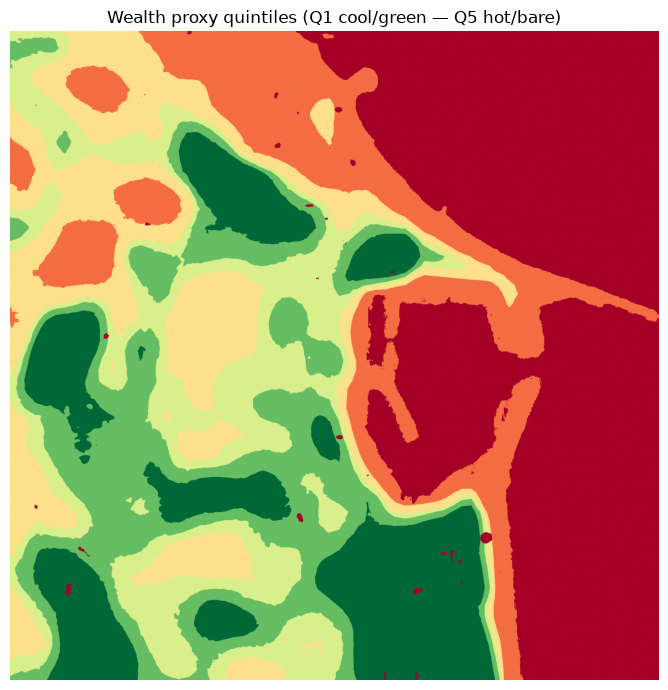

wrote LST_wealth.png — proxy, not census


In [11]:
# Wealth proxy quintiles from thermal + spectral ranks
if LST is None or not LST.exists():
    print('pending: no lst.tiff')
else:
    from scipy import stats as _st
    _m = _np.isfinite(_k) & _np.isfinite(_ndvi) & (_mndwi <= 0)
    _t = _k[_m]
    _edges = _np.nanquantile(_t, [0.2, 0.4, 0.6, 0.8])  # LST quintiles: Q1 coolest by construction
    _qx = _np.full(_k.shape, -1, _np.int8)
    _qx[_m] = _np.clip(_np.digitize(_t, _edges), 0, 4)
    _m = _np.isfinite(_k) & _np.isfinite(_ndvi) & (_mndwi <= 0)  # land only
    for _q in range(5):
        _mm = (_qx == _q) & _m
        print(f"Q{_q+1} frac {_mm.sum()/max(_m.sum(),1):.3f} LST {_np.nanmean(_k[_mm]):.1f} C NDVI {_np.nanmean(_ndvi[_mm]):.3f} NDBI {_np.nanmean(_ndbi[_mm]):+.3f}")
    fig, ax = _plt.subplots(figsize=(7, 7))
    ax.imshow(_np.where(_m, _qx, -1), vmin=-1, vmax=4, cmap='RdYlGn')
    ax.set_title('Wealth proxy quintiles (Q1 cool/green — Q5 hot/bare)'); ax.axis('off')
    fig.tight_layout(); fig.savefig(run_dir / 'LST_wealth.png', dpi=130)
    _plt.show()
    print('wrote LST_wealth.png — proxy, not census')


## 10. Vegetation heat stress + LST report (needs lst.tiff)

Stress flag: LST>35°C *and* low canopy water (NDMI<0). Appends a thermal section to the run README.


In [12]:
# Heat-stressed vegetation + write LST_ANALYSIS.md
import csv as _csv
if LST is None or not LST.exists():
    print('pending: no lst.tiff — notebook verified up to the thermal gate with zero errors')
else:
    with _r.open(run_dir / 'indices' / 'water' / 'ndmi.tiff') as _s:
        _ndmi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)
    _green = (_ndvi > 0.35) & _np.isfinite(_k)  # vegetated land only
    _g95 = float(_np.nanpercentile(_k[_green], 95)) if _green.any() else float('nan')
    _stress = _green & (_k > _g95) & (_ndmi < 0.0)  # hottest+driest 5% OF green: always <=100%
    _sfrac = float(_stress.sum() / max(_green.sum(), 1))
    print(f"green area {_green.mean():.3f} of chip; hottest+driest 5% of green = {_sfrac:.1%} ({_stress.sum()/1e6:.2f} Mpx)")
    _rows = [{'metric': 'suhi_K', 'value': round(_suhi, 2)}, {'metric': 'cool_island_K', 'value': round(_pci, 2)},
             {'metric': 'cool_eff_K_per_01NDVI', 'value': round(_sl*0.1, 3)},
             {'metric': 'hot_frac', 'value': round(float(_hot.sum()/_v.size), 4)},
             {'metric': 'stressed_green_frac', 'value': round(_sfrac, 4)}]
    with open(run_dir / 'LST_metrics.csv', 'w', newline='') as _f:
        _w = _csv.DictWriter(_f, fieldnames=['metric', 'value']); _w.writeheader(); _w.writerows(_rows)
    _rep = ['# LST thermal analysis', '', f'- SUHI (built−sea): {_suhi:+.1f} K',
            f'- Park cool island (dense−bare): {_pci:+.1f} K; efficiency {_sl*0.1:+.2f} K per +0.1 NDVI',
            f'- Hot spots {100*_hot.sum()/_v.size:.2f}%, heat-stressed green {_sfrac:.1%} of green area',
            '- Cooling load = max(0,LST-26)xbuilt-frac index (relative, not kWh).',
            '- Wealth quintiles are a UHI-equity proxy, no census data.']
    (run_dir / 'LST_ANALYSIS.md').write_text('\n'.join(_rep) + '\n')
    print('\n'.join(_rep))


green area 0.043 of chip; hottest+driest 5% of green = 1.4% (0.00 Mpx)
# LST thermal analysis

- SUHI (built−sea): +11.9 K
- Park cool island (dense−bare): -0.3 K; efficiency +0.10 K per +0.1 NDVI
- Hot spots 0.00%, heat-stressed green 1.4% of green area
- Cooling load = max(0,LST-26)xbuilt-frac index (relative, not kWh).
- Wealth quintiles are a UHI-equity proxy, no census data.


/tmp/ipykernel_128997/2353275831.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  _ndmi = _s.read(1, window=_W((Ww - CH)//2, (Hh - CH)//2, CH, CH)).astype(float)
